Cell 1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

2026-05-20 07:48:34.750001: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779263314.952664      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779263315.012881      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779263315.501313      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779263315.501351      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779263315.501357      57 computation_placer.cc:177] computation placer alr

Cell 2 — Load Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/robikscube/hourly-energy-consumption/PJME_hourly.csv')

print(df.head())

              Datetime  PJME_MW
0  2002-12-31 01:00:00  26498.0
1  2002-12-31 02:00:00  25147.0
2  2002-12-31 03:00:00  24574.0
3  2002-12-31 04:00:00  24393.0
4  2002-12-31 05:00:00  24860.0


✅ Cell 3 — Data Selection + Scaling

In [3]:
# Convert datetime (optional but good practice)
df['Datetime'] = pd.to_datetime(df['Datetime'])

# Sort by time (important for LSTM)
df = df.sort_values('Datetime')

# Select energy column
data = df['PJME_MW'].values

# Reshape for scaler
data = data.reshape(-1, 1)

# Normalize data (0 to 1)
scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

print(data_scaled[:5])

[[0.3339092 ]
 [0.31014432]
 [0.29101443]
 [0.28136522]
 [0.28469399]]


✅ Cell 4 — Create Time Series Sequences (12-step window)

In [4]:
def create_sequences(data, time_steps=12):
    X = []
    y = []

    for i in range(len(data) - time_steps):
        X.append(data[i:i+time_steps])
        y.append(data[i+time_steps])

    return np.array(X), np.array(y)

X, y = create_sequences(data_scaled, 12)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (145354, 12, 1)
y shape: (145354, 1)


✅ Cell 5 — Train/Test Split

In [5]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (116283, 12, 1)
X_test: (29071, 12, 1)
y_train: (116283, 1)
y_test: (29071, 1)


✅ Cell 6 — LSTM Model (MSE Loss)

In [6]:
model_mse = Sequential([
    LSTM(32, input_shape=(12, 1)),
    Dense(1)
])

model_mse.compile(
    optimizer='adam',
    loss='mse'
)

history_mse = model_mse.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20


2026-05-20 07:53:38.203272: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3634/3634 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - loss: 0.0045 - val_loss: 2.0740e-04
Epoch 2/20
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 2.3017e-04 - val_loss: 1.3705e-04
Epoch 3/20
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 2.1288e-04 - val_loss: 1.5547e-04
Epoch 4/20
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 1.9556e-04 - val_loss: 1.5245e-04
Epoch 5/20
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 1.7289e-04 - val_loss: 1.2010e-04
Epoch 6/20
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 1.5929e-04 - val_loss: 1.1803e-04
Epoch 7/20
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 1.5431e-04 - val_loss: 1.2033e-04
Epoch 8/20
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 1.4902e-04 - val_loss: 1.1071e-04
Epoch 9/20
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 1.4062e-04 - val_loss: 9.6283e-05
Epoch 10/20
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 1.2772e-04 - val_loss: 8.8494e-05
Epoch 11/20
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 2

✅ Cell 7 — Robust Model (Huber Loss)

In [7]:
model_huber = Sequential([
    LSTM(32, input_shape=(12, 1)),
    Dense(1)
])

model_huber.compile(
    optimizer='adam',
    loss='huber'
)

history_huber = model_huber.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 23s 6ms/step - loss: 0.0026 - val_loss: 1.3962e-04
Epoch 2/20
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 1.4191e-04 - val_loss: 7.1338e-05
Epoch 3/20
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 1.0865e-04 - val_loss: 6.9379e-05
Epoch 4/20
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 1.0716e-04 - val_loss: 6.9098e-05
Epoch 5/20
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 1.0091e-04 - val_loss: 6.7068e-05
Epoch 6/20
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 9.6475e-05 - val_loss: 6.9413e-05
Epoch 7/20
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - loss: 8.7916e-05 - val_loss: 6.6198e-05
Epoch 8/20
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 22s 6ms/step - loss: 8.2484e-05 - val_loss: 5.9020e-05
Epoch 9/20
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 7.6899e-05 - val_loss: 6.2156e-05
Epoch 10/20
3634/3634 ━━━━━━━━━━━━━━━━━━━━ 21s 6ms/step - loss: 7.2460e-05 - val_loss: 5.7503e-05
Epoch 11/20
3634/3634 ━━━━━━━━━━━

✅ Cell 8 — Predictions (Both Models)

In [8]:
# Predictions
pred_mse = model_mse.predict(X_test)
pred_huber = model_huber.predict(X_test)

print(pred_mse.shape, pred_huber.shape)

909/909 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
909/909 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
(29071, 1) (29071, 1)


✅ Cell 9 — Inverse Scaling

In [9]:
# Convert predictions back to original scale
pred_mse_inv = scaler.inverse_transform(pred_mse)
pred_huber_inv = scaler.inverse_transform(pred_huber)

y_test_inv = scaler.inverse_transform(y_test)

print(pred_mse_inv[:5])

[[32955.52 ]
 [33007.402]
 [32554.594]
 [33974.69 ]
 [32354.098]]


✅ Cell 10 — Metrics Comparison

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# MSE Model Metrics
mae_mse = mean_absolute_error(y_test_inv, pred_mse_inv)
mse_mse = mean_squared_error(y_test_inv, pred_mse_inv)

# Huber Model Metrics
mae_huber = mean_absolute_error(y_test_inv, pred_huber_inv)
mse_huber = mean_squared_error(y_test_inv, pred_huber_inv)

print("📊 MSE Model")
print("MAE:", mae_mse)
print("MSE:", mse_mse)

print("\n📊 Huber Model")
print("MAE:", mae_huber)
print("MSE:", mse_huber)

📊 MSE Model
MAE: 298.39512052657716
MSE: 176415.90094538612

📊 Huber Model
MAE: 313.69599932869096
MSE: 197417.55404214407


✅ Cell 11 — Visualization (100-hour comparison)

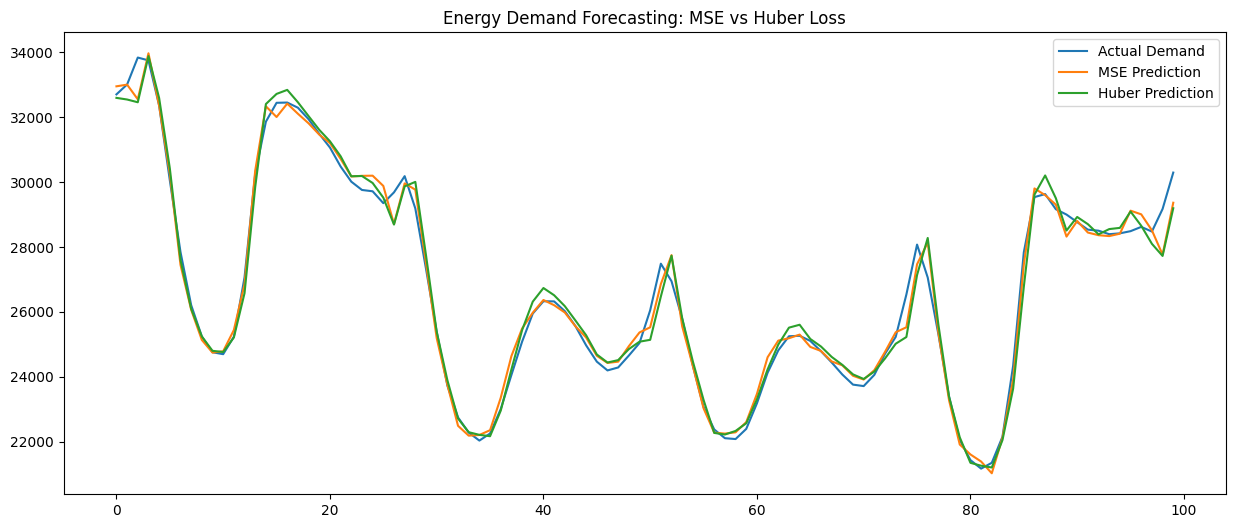

In [11]:
plt.figure(figsize=(15,6))

# first 100 samples only
plt.plot(y_test_inv[:100], label="Actual Demand")
plt.plot(pred_mse_inv[:100], label="MSE Prediction")
plt.plot(pred_huber_inv[:100], label="Huber Prediction")

plt.title("Energy Demand Forecasting: MSE vs Huber Loss")
plt.legend()
plt.show()

**The MSE loss function produces lower average error but is highly sensitive to sudden spikes in energy consumption due to its squared penalty. Huber loss reduces the impact of these extreme values by applying a linear penalty beyond a threshold. As a result, the Huber-based model provides a smoother and more stable prediction during volatile periods. Therefore, Huber loss is more reliable for real-world energy forecasting where outliers frequently occur.**